In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from scipy.special import legendre, factorial
import collections.abc
from essentials_bie import *
from density_bie import *
from sound_hard_bie import *

B_n (1+0j) jn -0.1917848549326277 dist 1.0
B_n 0 jn -0.0950894080791708 dist 1.0
B_n (1.8369701987210297e-16+3j) jn -0.0950894080791708 dist 1.0
B_n 0 jn -0.0950894080791708 dist 1.0
f [-0.96770331-0.25209184j -0.96770331-0.25209184j -0.96770331-0.25209184j
 -0.96770331-0.25209184j -0.96770331+0.25209184j -0.96770331+0.25209184j
 -0.96770331+0.25209184j -0.96770331+0.25209184j] fc [[-1.91784855e-01+0.j         -0.00000000e+00+0.j
  -1.74676409e-17-0.28526822j -0.00000000e+00+0.j        ]
 [-1.91784855e-01+0.j         -0.00000000e+00+0.j
  -1.74676409e-17-0.28526822j -0.00000000e+00+0.j        ]
 [-1.91784855e-01+0.j         -0.00000000e+00+0.j
  -1.74676409e-17-0.28526822j -0.00000000e+00+0.j        ]
 [-1.91784855e-01+0.j         -0.00000000e+00+0.j
  -1.74676409e-17-0.28526822j -0.00000000e+00+0.j        ]
 [-1.91784855e-01+0.j         -0.00000000e+00+0.j
  -1.74676409e-17-0.28526822j -0.00000000e+00+0.j        ]
 [-1.91784855e-01+0.j         -0.00000000e+00+0.j
  -1.74676409e-17-0.2

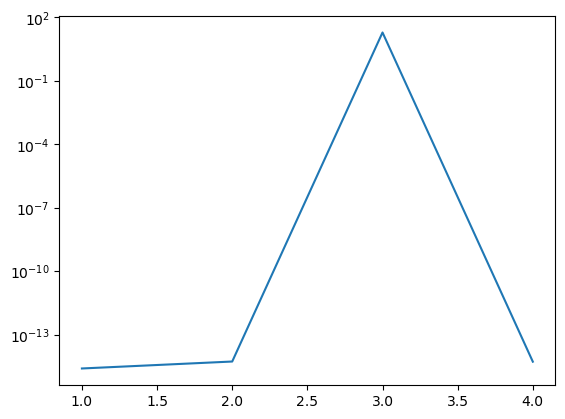

In [2]:
NN = 2
epsilon = np.array([1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])

error0 = np.zeros((len(epsilon)))
error1 = np.zeros((len(epsilon)))

KKw = 5

N = NN
M = 2*N
kw = KKw

# compute the Gauss-Legendre quadrature rule in s
zz, ϕ, mu, phi, WTS, ws = GaussLegendre( N )
s = 0.5 * np.pi * (zz + 1)
# compute the periodic trapezoid rule in t
dt = 2 * np.pi / M
t = np.arange(-np.pi, np.pi, dt)
        
# compute mesh grid
S, T = np.meshgrid(s, t)
Svec = S.flatten()
Tvec = T.flatten()

S2, T2 = np.meshgrid(np.arccos(zz), t)
Svec2 = S2.flatten()
Tvec2 = T2.flatten()
        
n_order = N
u_nm = Compute_data(n_order, kw)
#print('u_nm', u_nm)
u_nm= u_nm.flatten()
plt.figure()
plt.semilogy( np.arange(1,n_order**2+1), np.abs(u_nm) )

In [6]:
              
# loop over all ystar values
yll = [1]
for j in yll:
    #j = int((N * M / 16) if lll == 0 else (N * M / 4))
    #STANDAR PGQ
    theta02 = Svec2[j]
    phi02 = Tvec2[j]   
    _, _, ystar2, nustar2, _ = ComputeSurface(0, 0, theta02, phi02)
    theta2, phi2, y2, nu2, J2 = ComputeSurface(theta02, phi02, Svec2, Tvec2) 
    f2 = ComputeIncidentFunction(y2[:, 0], y2[:, 1], y2[:, 2], kw)
    df_coeffs2 = 1j*kw* (nu2[:,2]*f2)
    
    Ynm2, _, _ = ComputeSphericalHarmonics(n_order, theta2, phi2)
    Ynmstar2,_, _ = ComputeSphericalHarmonics(n_order, theta02, phi02)  
    
    u2 = Ynm2 @ u_nm
    ustar2 = Ynmstar2 @ u_nm
    #print('u2', u2, 'ustar2', ustar2)
    #NEW METHOD
    theta0 = Svec[j]
    phi0 = Tvec[j]
        
    _, _, ystar, nustar, _ = ComputeSurface(0, 0, theta0, phi0)
    theta, phi, y, nu, J = ComputeSurface(theta0, phi0, Svec, Tvec)
    f = ComputeIncidentFunction(y[:, 0], y[:, 1], y[:, 2], kw)
    df_coeffs = 1j*kw* (nu[:,2]*f)  
    Ynm, _, _ = ComputeSphericalHarmonics(n_order, theta, phi)
    Ynmstar,_, _ = ComputeSphericalHarmonics(n_order, theta0, phi0)
    
    u = Ynm @ u_nm
    ustar = Ynmstar @ u_nm
        
    # loop over all epsilon values
    for i in range(len(epsilon)):
        #PGQ
        x12 = ystar2[0] + epsilon[i] * nustar2[0,0]
        x22 = ystar2[1] + epsilon[i] * nustar2[0,1]
        x32 = ystar2[2] + epsilon[i] * nustar2[0,2]
        
        e_coeff2 = ComputeExpansionFunction(x12, x22, x32, kw, n_order)
        dist2 = np.sqrt(x12**2 + x22**2 + x32**2)
        #print('Ynm', Ynm, 'ecoeffs2', e_coeff2, 'h1', h1n(kw,dist2,n_order))
        etemp2 = np.repeat(e_coeff2 * h1n(kw,dist2,n_order), n_order)
        #print('prod', etemp2)
        exact2 = np.sum(Ynm  *etemp2.T)
        #print('exact2', np.size(exact2))
        Y12 = x12 - y2[:, 0]
        Y22 = x22 - y2[:, 1]
        Y32 = x32 - y2[:, 2]
        Ylength2 = np.sqrt(Y12**2 + Y22**2 + Y32**2)
        nu_nustar2 = np.sum(nustar2 * nu2, axis=1)
        nu_x_y2 = np.sum(nu2 * np.vstack((Y12, Y22, Y32)).T, axis=1)
        nustar_x_y2 = np.sum(nustar2 * np.vstack((Y12, Y22, Y32)).T, axis=1)
        
        SLP2 = 0.5 * J2 * np.exp(1j * kw * Ylength2) / Ylength2 * np.sin(Svec2)
        DLP2 = ((1 / Ylength2 - 1j * kw) * nu_x_y2 / Ylength2) * SLP2
        #print('u2', u2, 'ustar', ustar, 'exp', np.exp(-1j * kw * nustar_x_y2))
        PW2 = ustar2 * np.exp(-1j * kw * nustar_x_y2)
        
        #print('DLP2', DLP2, 'diff', u2 - PW2)
        Fbar12 = np.sum(((DLP2 * (u2 - PW2))).reshape(M, N), axis=0) / M
        Fbar112 = np.sum((SLP2 * (1j * kw * nu_nustar2 * PW2 + df_coeffs2)).reshape(M, N), axis=0) / M

        approx0 = np.sum((Fbar12 + Fbar112) * ws)

        #NEW METHOD
        # compute the evaluation point
        x1 = ystar[0] + epsilon[i] * nustar[0,0]
        x2 = ystar[1] + epsilon[i] * nustar[0,1]
        x3 = ystar[2] + epsilon[i] * nustar[0,2]
        
        e_coeff = ComputeExpansionFunction(x1, x2, x3, kw, n_order)
        dist = np.sqrt(x1**2 + x2**2 + x3**2)
        #print('Ynm', Ynm, 'ecoeffs', e_coeff, 'h1', h1n(kw,dist,n_order))
        etemp = np.repeat(e_coeff * h1n(kw,dist,n_order), n_order)
        #print('prod', etemp)
        exact = np.sum(Ynm  *etemp.T)
        
        #print('exact', exact)
        
        Y1 = x1 - y[:, 0]
        Y2 = x2 - y[:, 1]
        Y3 = x3 - y[:, 2]
        Ylength = np.sqrt(Y1**2 + Y2**2 + Y3**2)
        nu_nustar = np.sum(nustar * nu, axis=1)
        nu_x_y = np.sum(nu * np.vstack((Y1, Y2, Y3)).T, axis=1)
        nustar_x_y = np.sum(nustar * np.vstack((Y1, Y2, Y3)).T, axis=1)
        
        SLP = 0.5 * J * np.exp(1j * kw * Ylength) / Ylength * np.sin(Svec)
        DLP = ((1 / Ylength - 1j * kw) * nu_x_y / Ylength) * SLP
        PW = ustar * np.exp(-1j * kw * nustar_x_y)
        Fbar1 = np.sum(((DLP * (u - PW))).reshape(M, N), axis=0) / M
        Fbar11 = np.sum((SLP * (1j * kw * nu_nustar * PW + df_coeffs)).reshape(M, N), axis=0) / M

        approx1 = np.sum((Fbar1 + Fbar11) * ws)
        #print('approx', approx1)
                
        error0[i] = np.abs(exact - approx0)
        error1[i] = np.abs(exact2 -approx1)
        #error2[i] = np.abs(exact - approx2)
        #error3[i] = np.abs(exact - approx3)
                
        #errorN0[j, ss, i] = error0
        #errorN1[j, ss, i] = error1
        #errorN2[j, ss, i] = error2
        #errorN3[j, ss, i] = error3
                
        print('   j =', j, 'out of', N * M)
 

   j = 1 out of 512
   j = 1 out of 512
   j = 1 out of 512
   j = 1 out of 512
   j = 1 out of 512
   j = 1 out of 512
   j = 1 out of 512
   j = 1 out of 512
   j = 1 out of 512
   j = 1 out of 512
   j = 1 out of 512


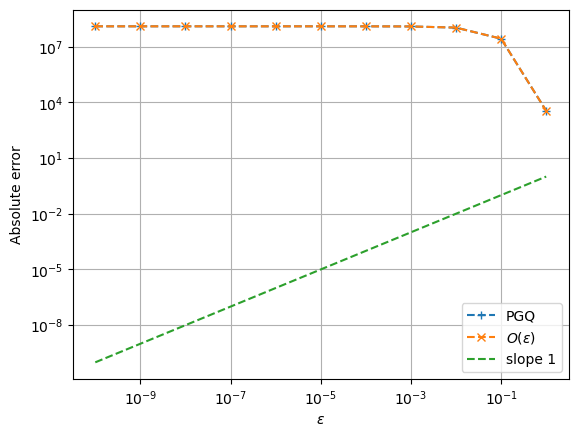

In [7]:
               
plt.figure()
plt.loglog(epsilon, error0, '--+', epsilon, error1, '--x', epsilon, epsilon, '--') 
#plt.loglog(epsilon, error0, 'k', epsilon, error1, '--x') #, epsilon, error2, '--o', epsilon, error3, '--.')
plt.xlabel('$\epsilon$')
plt.ylabel('Absolute error')
#plt.title('Error at point ' + str(j) + ', $\ell$ = ' + str(epsilon[i]))
plt.legend(['PGQ','$O(\epsilon)$', 'slope 1'], loc='best')
plt.grid(True)
#plt.ylim([1e-16, 1e1])
#plt.show()

#plt.savefig(f'helmholtz_Kw_{KKw}_N_{N}.png')
                        
#for lll in range(1,2):
#    for jj in range(len(epsilon)):
#        plt.figure()
#        plt.loglog(NN, errorN0[lll, :, jj], 'k--', NN, errorN1[lll, :, jj], '--x', NN, errorN2[lll, :, jj], '--o', NN,
#                   errorN3[lll, :, jj], '--.')
#        plt.xlabel('$N$')
#        plt.ylabel('Absolute error')
#        plt.title('Error at point ' + str(lll) + ', $\ell$ = ' + str(epsilon[jj]))
#        plt.legend(['V0', 'V1', 'V2', 'V3'], loc='best')
#        plt.grid(True)
#        plt.ylim([1e-16, 1e0])
#        plt.show()